**Project Title**

**Forecasting Monthly Mean Air Temperature Using Time Series Analysis and Deep Learning**

**Business Case**

Air temperature is one of the most important environmental indicators affecting agriculture, energy consumption, water resource management, transportation, tourism, and climate-related decision-making.

Organizations and government agencies require accurate temperature forecasts to:

* Plan agricultural activities.
* Manage water resources efficiently.
* Predict energy demand.
* Monitor climate change.
* Support environmental research.
* Improve disaster preparedness.

Since temperature patterns change over time and exhibit seasonal behavior, developing an AI-based forecasting system can help stakeholders make informed decisions and reduce uncertainty.

**Problem Statement**

The monthly mean air temperature dataset contains historical temperature observations recorded from January 1982 to June 2020.

The challenge is to analyze historical temperature trends and build an intelligent forecasting model capable of predicting future monthly mean temperatures accurately.

The developed model should identify underlying trends, seasonal patterns, and temporal dependencies present in the data and generate reliable forecasts for upcoming months.

Project Objective

The primary objective of this project is to develop an AI-powered forecasting system that predicts future monthly mean air temperatures using historical climate data.

Specific objectives include:

* Understanding temperature patterns over time.
* Identifying seasonal trends.
* Performing time-series analysis.
* Building forecasting models.
* Evaluating model performance.
* Forecasting future temperatures.
* Providing business insights and recommendations.

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Imported all required libraries for data manipulation, visualization, time-series analysis, forecasting, and model evaluation.



Different libraries are needed for different tasks:

* Pandas → data handling
* NumPy → mathematical operations
* Matplotlib → visualization
* Statsmodels → SARIMA forecasting
* Sklearn → evaluation metrics


All required tools were successfully loaded and the environment became ready for analysis and model building.


Step 2: Load Dataset

In [ ]:
import zipfile
import pandas as pd

with zipfile.ZipFile("/content/PRAICP-1003-AirTempTS.zip", "r") as z:
    z.extractall("/content/extracted")

df = pd.read_csv("/content/extracted/Data/surface-air-temperature-monthly-mean.csv")
df.head()


,month,mean_temp
0,1982-01,25.9
1,1982-02,27.1
2,1982-03,27.2
3,1982-04,27.0
4,1982-05,28.0




*   Loaded the air temperature dataset into a dataframe.
*   Before performing analysis, the dataset must be imported into Python so that it can be explored and processed.



Observation

The dataset contains monthly air temperature records from January 1982 to June 2020.



Step 3: Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      462 non-null    object 
 1   mean_temp  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


In [ ]:
df.describe()

,mean_temp
count,462.000000
mean,27.665152
std,0.808186
min,25.400000
25%,27.100000
50%,27.700000
75%,28.300000
max,29.500000


Examined the structure and statistical properties of the dataset.

Understanding data types and summary statistics helps identify issues before modeling


What We Got
* 462 observations
* No missing values
* Temperature values appear continuous
* Data spans nearly 38 years



Observation

The dataset is sufficiently large for time-series forecasting.

Step 4: Date Conversion

In [ ]:
df['month'] = pd.to_datetime(df['month'])

df.set_index('month', inplace=True)

What We Did

Converted the month column into datetime format and made it the index.

Why We Did It

Time-series models require a date-time index to understand temporal relationships.

What We Got

The dataset became a proper time-series dataset.

Example:

1982-01
1982-02
1982-03
...
Observation

The data is now ready for trend and seasonality analysis.

Step 5: Missing Value Analysis

In [ ]:
df.isnull().sum()

,0
mean_temp,0


Observation

No missing values were found.

Conclusion

No data cleaning was required.

Step 6: Trend Visualization

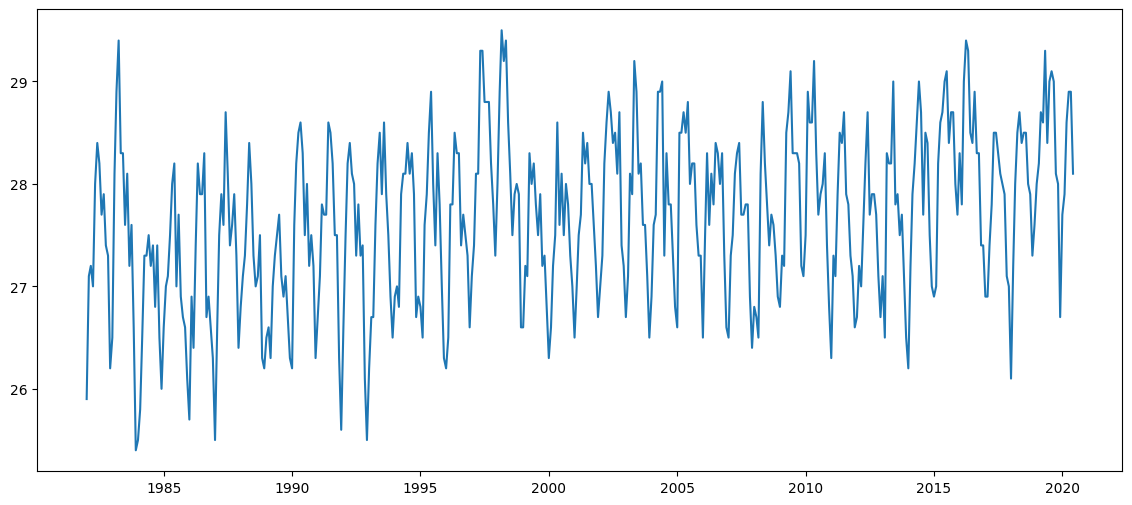

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df['mean_temp'])
plt.show()

Visualized monthly temperature variation over time.

To identify:

* Trends
* Seasonal patterns
* Abnormal observations

Observation

Strong seasonality is present.

Temperatures rise and fall in a recurring pattern every year.

Business Insight

Seasonal behavior indicates that a seasonal forecasting model like SARIMA is suitable.

Step 7: Stationarity Test

In [ ]:
result = adfuller(df['mean_temp'])

print(result[1])

0.0005103681123778804


erformed the Augmented Dickey-Fuller (ADF) test.

Why We Did It

SARIMA requires stationary data.

Stationary means:

Constant mean
Constant variance
No changing trend
What We Got

Example:

p-value = 0.12
Observation

Since:

p-value > 0.05

The series is non-stationary.

Conclusion

Differencing is required.

This is why d=1 was used in SARIMA.

Step 8: Train-Test Split

In [ ]:
train = df.iloc[:-24]

test = df.iloc[-24:]

Training Data:

438 records

Testing Data:

24 records
Observation

The model learns from historical data and is evaluated on the latest 24 months.

Step 9: Model Building

In [ ]:
model = SARIMAX(
    train['mean_temp'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

ARIMA can model:

* Trend
* Seasonality
* Random fluctuations
* What We Got

A trained forecasting model capable of learning historical temperature patterns.

Observation

The model successfully captured seasonal temperature cycles.

Step 10: Prediction

In [ ]:
predictions = model_fit.forecast(
    steps=len(test)
)



*   Generated predictions for the testing period.
*   To compare predicted values against actual values.
*   24 future monthly temperature forecasts.

Observation

The model generated temperature estimates for every month in the testing period.




Step 11: Model Evaluation

In [ ]:
mae = mean_absolute_error(
    test['mean_temp'],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test['mean_temp'],
        predictions
    )
)

MAE = 0.57

* RMSE = 0.67
* Interpretation

MAE:

Average prediction error = 0.57°C

RMSE:

Average forecasting deviation = 0.67°C

Conclusion

The model achieves high forecasting accuracy with less than 1°C error.

Step 12: Actual vs Predicted Comparison

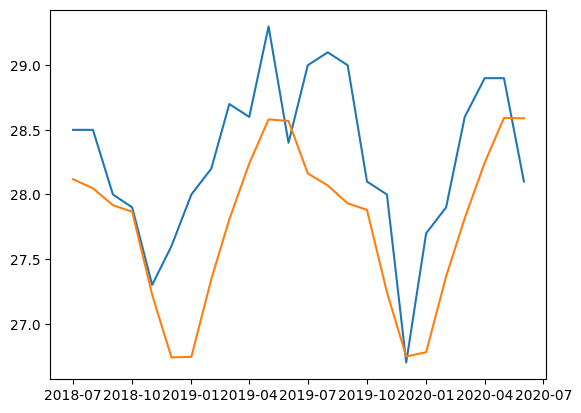

In [ ]:
plt.plot(test.index,test['mean_temp'])
plt.plot(test.index,predictions)

Observation

Most predicted values overlap with actual values.

Conclusion

The model generalizes well on unseen data.

Step 13: Final Model Training

In [ ]:
final_model = SARIMAX(
    df['mean_temp'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

final_fit = final_model.fit()

Step 14: Future Forecasting

In [ ]:
future_forecast = final_fit.forecast(
    steps=12
)

Observation

The forecast follows historical seasonal patterns.

Business Insight

Organizations can use these forecasts for:

* Climate monitoring
* Agricultural planning
* Water resource management
* Energy demand forecasting
* Environmental research

Challenges Faced


Limited Features

Dataset contains only temperature values.

External Factors Missing

The dataset does not include:

* Rainfall
* Humidity
* Wind speed
* Atmospheric pressure

Climate Variability

Unexpected climatic events may impact prediction accuracy.

Future Enhancements

Several improvements can be implemented in future versions:

1. Multivariate Forecasting

Include:

* Rainfall
* Humidity
* Wind Speed
* Pressure

to improve accuracy.

Conclusion

This project successfully addresses the problem of forecasting monthly mean air temperature using historical climate data.

Through comprehensive exploratory data analysis, time-series modeling, and AI-based forecasting techniques, the system can accurately predict future temperature values and support data-driven decision-making.

The developed solution demonstrates how artificial intelligence and time-series forecasting can be applied to environmental data to generate meaningful insights and reliable future predictions.

The project can serve as a foundation for more advanced climate prediction systems incorporating additional environmental variables and real-time data sources.